# **Handling Missing Values in Numerical Data**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.DataFrame({
    'salary':np.random.randint(30, 90, 20),
    'height':np.random.randint(120, 190, 20),
    'weight':np.random.randint(40, 90, 20)
})

In [3]:
df

,salary,height,weight
0,30,183,58
1,71,120,62
2,87,165,69
3,84,152,84
4,84,166,42
5,70,143,48
6,71,147,63
7,82,129,43
8,55,143,74
9,80,178,47


In [4]:
df.iloc[::2] = np.nan

In [5]:
df

,salary,height,weight
0,NaN,NaN,NaN
1,71.0,120.0,62.0
2,NaN,NaN,NaN
3,84.0,152.0,84.0
4,NaN,NaN,NaN
5,70.0,143.0,48.0
6,NaN,NaN,NaN
7,82.0,129.0,43.0
8,NaN,NaN,NaN
9,80.0,178.0,47.0


In [6]:
df['salary'].fillna(df['salary'].median(), inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_8832\995304906.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['salary'].fillna(df['salary'].median(), inplace=True)


In [7]:
df

,salary,height,weight
0,75.0,NaN,NaN
1,71.0,120.0,62.0
2,75.0,NaN,NaN
3,84.0,152.0,84.0
4,75.0,NaN,NaN
5,70.0,143.0,48.0
6,75.0,NaN,NaN
7,82.0,129.0,43.0
8,75.0,NaN,NaN
9,80.0,178.0,47.0


In [8]:
from sklearn.impute import SimpleImputer

In [9]:
impute = SimpleImputer(strategy='median')
impute

SimpleImputer(strategy='median')

In [10]:
impute.fit(df)

SimpleImputer(strategy='median')

In [11]:
impute.statistics_

array([ 75., 144.,  63.])

In [12]:
df.describe()

,salary,height,weight
count,20.000000,10.000000,10.000000
mean,71.250000,144.100000,65.300000
std,13.439435,18.199206,17.204973
min,41.000000,120.000000,43.000000
25%,74.000000,129.750000,50.750000
50%,75.000000,144.000000,63.000000
75%,76.000000,151.750000,80.000000
max,85.000000,178.000000,89.000000


In [13]:
df_tr = impute.transform(df)
df_tr

array([[ 75., 144.,  63.],
       [ 71., 120.,  62.],
       [ 75., 144.,  63.],
       [ 84., 152.,  84.],
       [ 75., 144.,  63.],
       [ 70., 143.,  48.],
       [ 75., 144.,  63.],
       [ 82., 129.,  43.],
       [ 75., 144.,  63.],
       [ 80., 178.,  47.],
       [ 75., 144.,  63.],
       [ 42., 151.,  89.],
       [ 75., 144.,  63.],
       [ 85., 165.,  89.],
       [ 75., 144.,  63.],
       [ 41., 132.,  59.],
       [ 75., 144.,  63.],
       [ 41., 126.,  64.],
       [ 75., 144.,  63.],
       [ 79., 145.,  68.]])

In [14]:
df

,salary,height,weight
0,75.0,NaN,NaN
1,71.0,120.0,62.0
2,75.0,NaN,NaN
3,84.0,152.0,84.0
4,75.0,NaN,NaN
5,70.0,143.0,48.0
6,75.0,NaN,NaN
7,82.0,129.0,43.0
8,75.0,NaN,NaN
9,80.0,178.0,47.0


In [15]:
df_tr

array([[ 75., 144.,  63.],
       [ 71., 120.,  62.],
       [ 75., 144.,  63.],
       [ 84., 152.,  84.],
       [ 75., 144.,  63.],
       [ 70., 143.,  48.],
       [ 75., 144.,  63.],
       [ 82., 129.,  43.],
       [ 75., 144.,  63.],
       [ 80., 178.,  47.],
       [ 75., 144.,  63.],
       [ 42., 151.,  89.],
       [ 75., 144.,  63.],
       [ 85., 165.,  89.],
       [ 75., 144.,  63.],
       [ 41., 132.,  59.],
       [ 75., 144.,  63.],
       [ 41., 126.,  64.],
       [ 75., 144.,  63.],
       [ 79., 145.,  68.]])

In [16]:
impute.get_feature_names_out()

array(['salary', 'height', 'weight'], dtype=object)

In [17]:
pd.DataFrame(df_tr, columns=impute.get_feature_names_out())

,salary,height,weight
0,75.0,144.0,63.0
1,71.0,120.0,62.0
2,75.0,144.0,63.0
3,84.0,152.0,84.0
4,75.0,144.0,63.0
5,70.0,143.0,48.0
6,75.0,144.0,63.0
7,82.0,129.0,43.0
8,75.0,144.0,63.0
9,80.0,178.0,47.0


# **Feature Scaling**

In [18]:
house = pd.read_csv('housing.csv')
house

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [19]:
X = house.drop(['ocean_proximity', 'median_house_value'], axis=1)
y = house.median_house_value

In [20]:
X

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462
...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672


In [21]:
y

0        452600.0
1        358500.0
2        352100.0
3        341300.0
4        342200.0
           ...   
20635     78100.0
20636     77100.0
20637     92300.0
20638     84700.0
20639     89400.0
Name: median_house_value, Length: 20640, dtype: float64

In [22]:
X

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462
...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672


In [23]:
X.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100


In [24]:
data = X['total_rooms'].values
data

array([ 880., 7099., 1467., ..., 2254., 1860., 2785.])

In [25]:
data.min()

2.0

In [26]:
data.max()

39320.0

In [27]:
def normalization(x):
    normalized_data = abs(x.mean() - x) / np.std(x)
    return normalized_data

In [28]:
normalized = normalization(data)
normalized

array([0.8048191 , 2.0458901 , 0.53574589, ..., 0.17499526, 0.35559977,
       0.06840827])

In [29]:
normalized.min()

0.00010860042530193474

In [30]:
normalized.max()

16.815579920800463

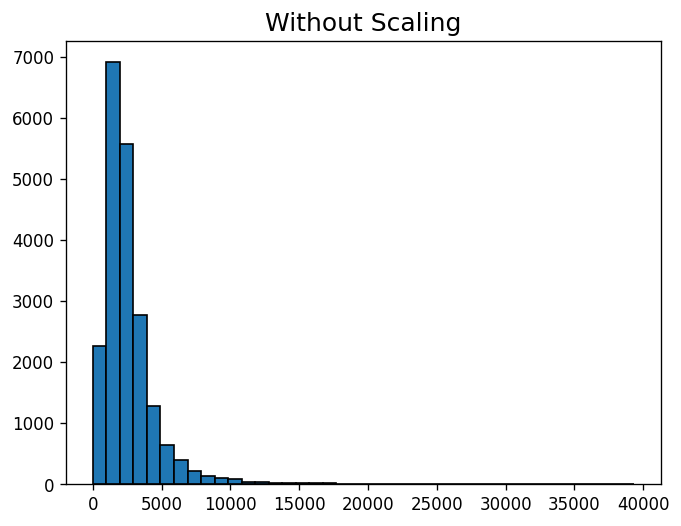

In [31]:
plt.figure(dpi=120)
plt.hist(data, bins=40, ec='k')
plt.title("Without Scaling", size=15)
plt.show()

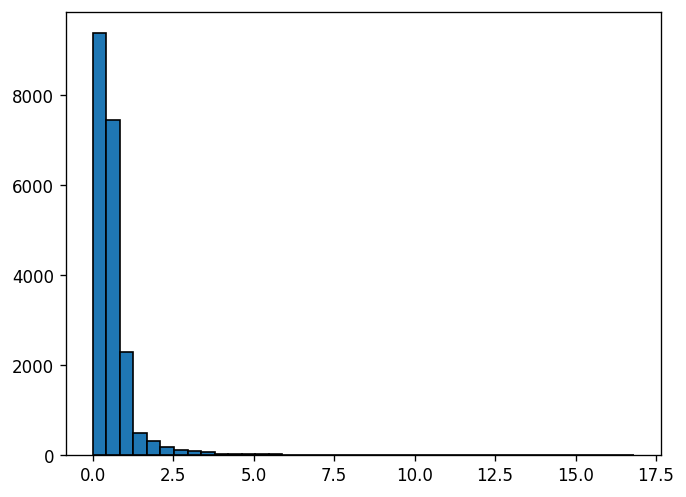

In [32]:
plt.figure(dpi=120)
plt.hist(normalized, bins=40, ec='k')
plt.show()

In [33]:
X

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462
...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672


In [34]:
from sklearn.preprocessing import StandardScaler

In [35]:
scale = StandardScaler()
scale.fit(X)

StandardScaler()

In [36]:
scale.mean_

array([-119.56970446,   35.63186143,   28.63948643, 2635.7630814 ,
        537.87055254, 1425.47674419,  499.53968023,    3.870671  ])

In [37]:
scale.var_

array([4.01394488e+00, 4.56207160e+00, 1.58388586e+02, 4.75921451e+06,
       1.77556687e+05, 1.28240832e+06, 1.46168958e+05, 3.60914769e+00])

In [38]:
scale.transform(X)

array([[-1.32783522,  1.05254828,  0.98214266, ..., -0.9744286 ,
        -0.97703285,  2.34476576],
       [-1.32284391,  1.04318455, -0.60701891, ...,  0.86143887,
         1.66996103,  2.33223796],
       [-1.33282653,  1.03850269,  1.85618152, ..., -0.82077735,
        -0.84363692,  1.7826994 ],
       ...,
       [-0.8237132 ,  1.77823747, -0.92485123, ..., -0.3695372 ,
        -0.17404163, -1.14259331],
       [-0.87362627,  1.77823747, -0.84539315, ..., -0.60442933,
        -0.39375258, -1.05458292],
       [-0.83369581,  1.75014627, -1.00430931, ..., -0.03397701,
         0.07967221, -0.78012947]])

In [39]:
scale.get_feature_names_out()

array(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype=object)

In [40]:
X_tr = pd.DataFrame(scale.transform(X), columns=scale.get_feature_names_out())
X_tr

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-1.327835,1.052548,0.982143,-0.804819,-0.970325,-0.974429,-0.977033,2.344766
1,-1.322844,1.043185,-0.607019,2.045890,1.348276,0.861439,1.669961,2.332238
2,-1.332827,1.038503,1.856182,-0.535746,-0.825561,-0.820777,-0.843637,1.782699
3,-1.337818,1.038503,1.856182,-0.624215,-0.718768,-0.766028,-0.733781,0.932968
4,-1.337818,1.038503,1.856182,-0.462404,-0.611974,-0.759847,-0.629157,-0.012881
...,...,...,...,...,...,...,...,...
20635,-0.758826,1.801647,-0.289187,-0.444985,-0.388895,-0.512592,-0.443449,-1.216128
20636,-0.818722,1.806329,-0.845393,-0.888704,-0.920488,-0.944405,-1.008420,-0.691593
20637,-0.823713,1.778237,-0.924851,-0.174995,-0.125472,-0.369537,-0.174042,-1.142593
20638,-0.873626,1.778237,-0.845393,-0.355600,-0.305834,-0.604429,-0.393753,-1.054583


In [41]:
X_tr.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
count,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.043300e+04,2.064000e+04,2.064000e+04,2.064000e+04
mean,-8.526513e-15,-1.079584e-15,5.508083e-18,3.201573e-17,-7.233049e-17,-1.101617e-17,6.885104e-17,6.609700e-17
std,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00
min,-2.385992e+00,-1.447568e+00,-2.196180e+00,-1.207283e+00,-1.274093e+00,-1.256123e+00,-1.303984e+00,-1.774299e+00
25%,-1.113209e+00,-7.967887e-01,-8.453931e-01,-5.445698e-01,-5.740034e-01,-5.638089e-01,-5.742294e-01,-6.881186e-01
50%,5.389137e-01,-6.422871e-01,2.864572e-02,-2.332104e-01,-2.441308e-01,-2.291318e-01,-2.368162e-01,-1.767951e-01
75%,7.784964e-01,9.729566e-01,6.643103e-01,2.348028e-01,2.589843e-01,2.644949e-01,2.758427e-01,4.593063e-01
max,2.625280e+00,2.958068e+00,1.856182e+00,1.681558e+01,1.401871e+01,3.025033e+01,1.460152e+01,5.858286e+00


<function matplotlib.pyplot.show(close=None, block=None)>

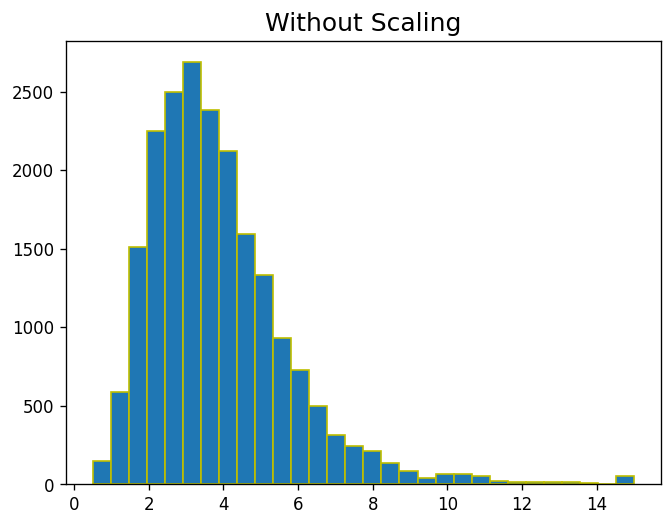

In [42]:
plt.figure(dpi=120)
plt.hist(X['median_income'], bins=30, ec='y')
plt.title('Without Scaling', size=15)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

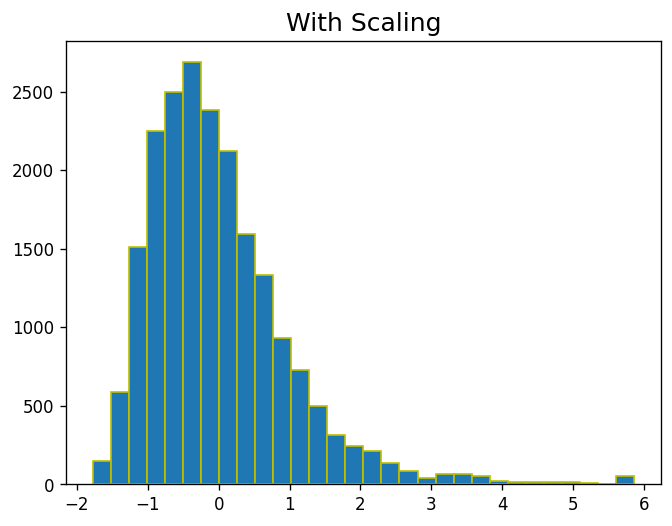

In [43]:
plt.figure(dpi=120)
plt.hist(X_tr['median_income'], bins=30, ec='y')
plt.title('With Scaling', size=15)
plt.show

# **Handling Categorical Values**

In [44]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

In [45]:
df = pd.DataFrame({
    'performance':np.random.choice(['poor', 'avg', 'good'], 20),
    'student_grades':np.random.choice(['A', 'B', 'C', 'D'], 20)
})
df

,performance,student_grades
0,good,D
1,poor,C
2,good,C
3,good,A
4,good,B
5,poor,B
6,poor,D
7,good,B
8,poor,A
9,avg,C


In [46]:
ordinal = OrdinalEncoder()
ordinal

OrdinalEncoder()

In [47]:
ordinal.fit(df)

OrdinalEncoder()

In [48]:
ordinal.categories_

[array(['avg', 'good', 'poor'], dtype=object),
 array(['A', 'B', 'C', 'D'], dtype=object)]

In [49]:
df_tr = ordinal.transform(df)
df_tr

array([[1., 3.],
       [2., 2.],
       [1., 2.],
       [1., 0.],
       [1., 1.],
       [2., 1.],
       [2., 3.],
       [1., 1.],
       [2., 0.],
       [0., 2.],
       [0., 1.],
       [0., 1.],
       [2., 1.],
       [0., 3.],
       [0., 0.],
       [0., 1.],
       [0., 3.],
       [1., 3.],
       [2., 3.],
       [2., 0.]])

In [50]:
ordinal.feature_names_in_

array(['performance', 'student_grades'], dtype=object)

In [51]:
ordinal.get_feature_names_out()

array(['performance', 'student_grades'], dtype=object)

In [52]:
pd.DataFrame(df_tr, columns=ordinal.get_feature_names_out())

,performance,student_grades
0,1.0,3.0
1,2.0,2.0
2,1.0,2.0
3,1.0,0.0
4,1.0,1.0
5,2.0,1.0
6,2.0,3.0
7,1.0,1.0
8,2.0,0.0
9,0.0,2.0


In [53]:
df = pd.DataFrame({
    'gender':np.random.choice(['male', 'female'], 20),
    'fruits':np.random.choice(['apple', 'banana', 'papaya', 'pineapple'], 20)
})
df

,gender,fruits
0,female,banana
1,female,papaya
2,male,apple
3,male,apple
4,male,banana
5,female,papaya
6,female,pineapple
7,female,papaya
8,male,pineapple
9,male,apple


In [54]:
one_hot = OneHotEncoder()
one_hot

OneHotEncoder()

In [55]:
one_hot.fit(df)

OneHotEncoder()

In [56]:
one_hot.categories_

[array(['female', 'male'], dtype=object),
 array(['apple', 'banana', 'papaya', 'pineapple'], dtype=object)]

In [57]:
one_hot.transform(df)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 40 stored elements and shape (20, 6)>

In [58]:
v = one_hot.transform(df)
v.toarray()

array([[1., 0., 0., 1., 0., 0.],
       [1., 0., 0., 0., 1., 0.],
       [0., 1., 1., 0., 0., 0.],
       [0., 1., 1., 0., 0., 0.],
       [0., 1., 0., 1., 0., 0.],
       [1., 0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 1., 0.],
       [0., 1., 0., 0., 0., 1.],
       [0., 1., 1., 0., 0., 0.],
       [1., 0., 0., 0., 1., 0.],
       [0., 1., 0., 0., 1., 0.],
       [0., 1., 0., 1., 0., 0.],
       [1., 0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0., 1.],
       [1., 0., 1., 0., 0., 0.],
       [1., 0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 1., 0.],
       [0., 1., 0., 0., 0., 1.],
       [1., 0., 0., 0., 1., 0.]])

In [59]:
one_hot.feature_names_in_

array(['gender', 'fruits'], dtype=object)

In [60]:
one_hot.get_feature_names_out()

array(['gender_female', 'gender_male', 'fruits_apple', 'fruits_banana',
       'fruits_papaya', 'fruits_pineapple'], dtype=object)

In [61]:
pd.DataFrame(v.toarray(), columns=one_hot.get_feature_names_out())

,gender_female,gender_male,fruits_apple,fruits_banana,fruits_papaya,fruits_pineapple
0,1.0,0.0,0.0,1.0,0.0,0.0
1,1.0,0.0,0.0,0.0,1.0,0.0
2,0.0,1.0,1.0,0.0,0.0,0.0
3,0.0,1.0,1.0,0.0,0.0,0.0
4,0.0,1.0,0.0,1.0,0.0,0.0
5,1.0,0.0,0.0,0.0,1.0,0.0
6,1.0,0.0,0.0,0.0,0.0,1.0
7,1.0,0.0,0.0,0.0,1.0,0.0
8,0.0,1.0,0.0,0.0,0.0,1.0
9,0.0,1.0,1.0,0.0,0.0,0.0


# **Feature Engineering**

In [62]:
X

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462
...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672


In [63]:
y

0        452600.0
1        358500.0
2        352100.0
3        341300.0
4        342200.0
           ...   
20635     78100.0
20636     77100.0
20637     92300.0
20638     84700.0
20639     89400.0
Name: median_house_value, Length: 20640, dtype: float64

In [64]:
lat_long = X['latitude'] + X['longitude']
lat_long

0       -84.35
1       -84.36
2       -84.39
3       -84.40
4       -84.40
         ...  
20635   -81.61
20636   -81.72
20637   -81.79
20638   -81.89
20639   -81.87
Length: 20640, dtype: float64

In [65]:
np.corrcoef(lat_long, y)

array([[ 1.        , -0.49151968],
       [-0.49151968,  1.        ]])

In [66]:
X

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462
...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672


In [67]:
n = X['total_rooms'] / X['households']
n

0        6.984127
1        6.238137
2        8.288136
3        5.817352
4        6.281853
           ...   
20635    5.045455
20636    6.114035
20637    5.205543
20638    5.329513
20639    5.254717
Length: 20640, dtype: float64

In [68]:
np.corrcoef(n, y)

array([[1.        , 0.15194829],
       [0.15194829, 1.        ]])

In [69]:
hs_pop = X['households'] / X['population']
hs_pop

0        0.391304
1        0.473969
2        0.356855
3        0.392473
4        0.458407
           ...   
20635    0.390533
20636    0.320225
20637    0.429990
20638    0.470985
20639    0.382120
Length: 20640, dtype: float64

In [70]:
np.corrcoef(n, y)

array([[1.        , 0.15194829],
       [0.15194829, 1.        ]])

In [71]:
house.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [72]:
house.dropna(inplace=True)

In [73]:
bd_rm = house['total_bedrooms'] / house['total_rooms']
bd_rm

0        0.146591
1        0.155797
2        0.129516
3        0.184458
4        0.172096
           ...   
20635    0.224625
20636    0.215208
20637    0.215173
20638    0.219892
20639    0.221185
Length: 20433, dtype: float64

In [74]:
np.corrcoef(bd_rm, house['median_house_value'])

array([[ 1.        , -0.25588015],
       [-0.25588015,  1.        ]])